### Import Library

Bagian ini memuat library utama yang digunakan dalam pipeline forecasting cuaca:

- **`os`** → operasi sistem file (path, direktori, listing file).  
- **`numpy`** → komputasi numerik berbasis array.  
- **`pandas`** → manipulasi data tabular (DataFrame).  
- **`tensorflow`** → framework deep learning.  
- **`keras.models, keras.layers`** → membangun dan memuat model.  
- **`ImageDataGenerator`** → augmentasi data gambar (tidak dipakai di time series, tapi tersedia).  
- **`StandardScaler, LabelEncoder`** → normalisasi fitur numerik & encoding label kategori.  
- **`classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score`** → evaluasi performa model.  
- **`train_test_split`** → membagi dataset menjadi train/val/test.  
- **`matplotlib.pyplot`** → visualisasi hasil training dan evaluasi.  


In [11]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Lambda
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### Konfigurasi Awal (Seed, Path, dan Parameter)

Bagian ini mendefinisikan **seed**, **path model/dataset**, serta parameter penting untuk pipeline forecasting cuaca.

#### 1. Reproducibility
- **`SEED = 42`** → nilai seed untuk random number generator.  
- **`np.random.seed(SEED)`** → memastikan operasi acak NumPy konsisten.  
- **`tf.random.set_seed(SEED)`** → memastikan operasi acak TensorFlow konsisten.  
- Tujuan: hasil eksperimen dapat direproduksi dengan konsisten.

#### 2. Path Model
- **`CNN_MODEL_PATH`** → lokasi file model CNN (`cnn_model.h5`).  
- **`BILSTM_MODEL_PATH`** → lokasi file model BiLSTM (`model_bilstm_h1.h5`).  
- **`TCN_MODEL_PATH`** → lokasi file model TCN (`model_tcn_h1.h5`).  
- Semua model disimpan di folder `../Result Model/`.

#### 3. Path Dataset
- **`IMG_TEST_DIR`** → direktori dataset gambar awan untuk pengujian.  
- **`FC_CSV_PATH`** → file CSV dataset cuaca Manokwari (suhu, kelembapan, tekanan, angin, label cuaca).  
- **`META_CSV_PATH`** → file metadata untuk dataset gambar awan.  

#### 4. Kolom & Parameter
- **`TIME_COLUMN = "datetime"`** → kolom waktu pada dataset cuaca.  
- **`TARGET_COLUMN = "cuaca"`** → kolom target label cuaca.  
- **`SEQ_LEN = 24`** → panjang sequence input (24 jam terakhir).  
- **`ALPHA_DAY = 0.7`** → bobot CNN saat siang hari (06–18).  
  - Artinya, prediksi CNN lebih dominan pada jam siang dibanding model time series.  

#### 5. Catatan
- Konfigurasi ini menghubungkan model berbasis gambar (CNN) dengan model berbasis time series (BiLSTM, TCN).  
- Bobot **ALPHA_DAY** memungkinkan ensemble adaptif: CNN lebih dipercaya saat siang, sedangkan BiLSTM/TCN lebih dominan saat malam.


In [12]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CNN_MODEL_PATH    = r"../Result Model/cnn_model.h5"
BILSTM_MODEL_PATH = r"../Result Model/model_bilstm_h1.h5"
TCN_MODEL_PATH    = r"../Result Model/model_tcn_h1.h5"

IMG_TEST_DIR   = r"../Dataset/Awan/test"
FC_CSV_PATH    = r"../Dataset/Suhu/Prakiraan/dataset_cuaca_manokwari.csv"
META_CSV_PATH  = r"../Dataset/Awan/test_metadata.csv"

TIME_COLUMN    = "datetime"
TARGET_COLUMN  = "cuaca"
SEQ_LEN        = 24
ALPHA_DAY      = 0.7  # bobot CNN saat siang (06–18)

### Utility Functions untuk Preprocessing Time Series Cuaca

Bagian ini berisi fungsi-fungsi bantu untuk memetakan label cuaca, menambahkan fitur waktu, membuat fitur turunan (berawan, angin), serta membentuk jendela input untuk model time series.

#### 1. `map_weather_class(label)`
- Memetakan variasi label cuaca BMKG ke tiga kelas utama: **Cerah**, **Berawan**, **Hujan**.  
- Contoh: *Cerah Berawan* → Berawan, *Hujan Ringan/Sedang/Petir* → Hujan.  
- Jika label tidak ada di mapping, fungsi mengembalikan label asli.

#### 2. `add_time_features(df, time_col)`
- Mengubah kolom waktu menjadi fitur numerik: jam, hari dalam minggu, bulan.  
- Menambahkan **encoding siklik** (sin/cos) agar pola wrap-around terjaga (misalnya jam 23 dekat dengan jam 0).  
- Berguna untuk menangkap pola harian, mingguan, dan musiman.

#### 3. `find_first(df, keys)`
- Mencari kolom pertama dalam DataFrame yang mengandung salah satu kata kunci.  
- Hanya mengembalikan kolom dengan tipe numerik.  
- Digunakan sebagai helper untuk mendeteksi kolom kelembapan, suhu, tekanan, radiasi.

#### 4. `add_berawan_features(df)`
- Menambahkan fitur turunan dari kelembapan, suhu, tekanan, radiasi.  
- Fitur berupa **selisih (diff)** 3 jam dan 6 jam untuk menangkap perubahan tren.  
- Fitur berupa **rolling standar deviasi** radiasi (3 jam, 6 jam) untuk mengukur variabilitas cahaya/awan.  
- Tujuan: membantu model mengenali kondisi berawan atau hujan dari dinamika atmosfer.

#### 5. `WIND_DIR_DEG`
- Kamus arah angin kardinal (N, NE, E, dst.) ke derajat kompas (0–360).  
- Digunakan untuk konversi arah angin ke representasi numerik.

#### 6. `add_wind_features(df, dir_col="arah_angin", speed_col="kecepatan_angin")`
- Normalisasi teks arah angin (Indonesia → simbol kardinal).  
- Konversi arah ke derajat, lalu encoding siklik (sin/cos).  
- Jika kecepatan angin tersedia, dihitung komponen vektor **wind_x** dan **wind_y**.  
- Memberikan representasi vektor angin yang lebih informatif untuk model.

#### 7. `make_windows(data, labels, seq_len, horizon=1)`
- Membentuk **sliding window** untuk data time series.  
- Input: sequence sepanjang `seq_len`, output: label pada posisi `seq_len + horizon - 1`.  
- Menghasilkan array fitur (`float32`) dan label (`int32`) siap untuk training.  
- Horizon default = 1 → prediksi 1 langkah ke depan (H+1).


In [13]:
def map_weather_class(label):
    mapping = {
        "Cerah": "Cerah",
        "Berawan": "Berawan",
        "Cerah Berawan": "Berawan",
        "Udara Kabur": "Berawan",
        "Hujan Ringan": "Hujan",
        "Hujan Sedang": "Hujan",
        "Hujan Petir": "Hujan",
        "Petir": "Hujan"
    }
    return mapping.get(label, label)

def add_time_features(df, time_col):
    dt = pd.to_datetime(df[time_col])
    df["hour"] = dt.dt.hour
    df["dayofweek"] = dt.dt.dayofweek
    df["month"] = dt.dt.month
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["dow_sin"]  = np.sin(2*np.pi*df["dayofweek"]/7)
    df["dow_cos"]  = np.cos(2*np.pi*df["dayofweek"]/7)
    df["mon_sin"]  = np.sin(2*np.pi*df["month"]/12)
    df["mon_cos"]  = np.cos(2*np.pi*df["month"]/12)
    return df

def find_first(df, keys):
    for c in df.columns:
        if any(k in c.lower() for k in keys):
            if pd.api.types.is_numeric_dtype(df[c]):
                return c
    return None

def add_berawan_features(df):
    rh    = find_first(df, ["rh", "humid", "kelembap", "kelembaban"])
    temp  = find_first(df, ["suhu", "temp"])
    press = find_first(df, ["tekan", "press"])
    rad   = find_first(df, ["radiasi", "solar", "sun"])
    if rh:
        df["rh_diff3"] = df[rh] - df[rh].shift(3)
        df["rh_diff6"] = df[rh] - df[rh].shift(6)
    if temp:
        df["temp_diff3"] = df[temp] - df[temp].shift(3)
        df["temp_diff6"] = df[temp] - df[temp].shift(6)
    if press:
        df["press_diff3"] = df[press] - df[press].shift(3)
        df["press_diff6"] = df[press] - df[press].shift(6)
    if rad:
        df["rad_std3"] = df[rad].rolling(3, min_periods=1).std()
        df["rad_std6"] = df[rad].rolling(6, min_periods=1).std()
    return df

WIND_DIR_DEG = {
    "N":0, "NNE":22.5, "NE":45, "ENE":67.5,
    "E":90, "ESE":112.5, "SE":135, "SSE":157.5,
    "S":180, "SSW":202.5, "SW":225, "WSW":247.5,
    "W":270, "WNW":292.5, "NW":315, "NNW":337.5
}

def add_wind_features(df, dir_col="arah_angin", speed_col="kecepatan_angin"):
    if dir_col in df.columns:
        d = df[dir_col].astype(str).str.upper().str.strip()
        d = d.replace({
            "TIMUR":"E","BARAT":"W","UTARA":"N","SELATAN":"S",
            "TENGGARA":"SE","BARAT DAYA":"SW","TIMUR LAUT":"NE","BARAT LAUT":"NW"
        }, regex=False)
        deg = d.map(WIND_DIR_DEG)
        fallback_deg = pd.to_numeric(d.str.replace("°","", regex=False), errors="coerce")
        deg = deg.fillna(fallback_deg)
        deg = deg % 360
        df["wind_deg"] = deg
        df["wind_sin"] = np.sin(2*np.pi*df["wind_deg"]/360.0)
        df["wind_cos"] = np.cos(2*np.pi*df["wind_deg"]/360.0)
        if speed_col in df.columns and pd.api.types.is_numeric_dtype(df[speed_col]):
            df["wind_x"] = df[speed_col] * df["wind_cos"]
            df["wind_y"] = df[speed_col] * df["wind_sin"]
    return df

def make_windows(data, labels, seq_len, horizon=1):
    Xs, ys = [], []
    N = len(data)
    for i in range(N - seq_len - horizon + 1):
        Xs.append(data[i:i+seq_len])
        ys.append(labels[i+seq_len+horizon-1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int32)

### Load Pretrained Models

Bagian ini memuat kembali model yang sudah dilatih dan disimpan sebelumnya, agar bisa digunakan untuk inference atau ensemble.

#### 1. CNN Model
- **`cnn_model = load_model(CNN_MODEL_PATH, compile=False)`**  
- Memuat model CNN dari file `cnn_model.h5`.  
- Parameter `compile=False` → model tidak perlu dikompilasi ulang saat load, cukup untuk inference.  

#### 2. BiLSTM Model
- **`bilstm_model = load_model(BILSTM_MODEL_PATH, compile=False)`**  
- Memuat model BiLSTM dari file `model_bilstm_h1.h5`.  
- Digunakan untuk prediksi berbasis time series (24 jam terakhir).  

#### 3. TCN Model
- **`tcn_model = load_model(TCN_MODEL_PATH, compile=False)`**  
- Memuat model TCN dari file `model_tcn_h1.h5`.  
- Digunakan untuk menangkap pola jangka panjang dengan dilasi pada time series.  

#### 4. Catatan
- Semua model dimuat dalam mode inference (tanpa compile ulang).  
- Model ini siap dipakai untuk ensemble forecasting: CNN (gambar awan) + BiLSTM/TCN (time series cuaca).


In [14]:
# ===================== Load models =====================
cnn_model    = load_model(CNN_MODEL_PATH, compile=False)
bilstm_model = load_model(BILSTM_MODEL_PATH, compile=False)
tcn_model    = load_model(TCN_MODEL_PATH, compile=False)

### Prediksi CNN & Urutan Kelas

Bagian ini menjalankan proses inference menggunakan model **CNN** pada dataset gambar awan, sekaligus menentukan urutan kelas yang konsisten dengan struktur direktori dataset.

#### 1. Augmentasi Data Uji
- **`ImageDataGenerator(rescale=1./255)`**  
  - Normalisasi piksel gambar dari [0–255] menjadi [0–1].  
  - Digunakan hanya untuk data uji (tanpa augmentasi tambahan).  

#### 2. Generator Data Uji
- **`flow_from_directory(IMG_TEST_DIR, ...)`**  
  - Membaca gambar dari direktori `IMG_TEST_DIR`.  
  - **`target_size=(224, 224)`** → semua gambar di-resize ke ukuran 224×224.  
  - **`batch_size=32`** → jumlah gambar per batch.  
  - **`class_mode='categorical'`** → label dikodekan dalam bentuk one-hot.  
  - **`shuffle=False`** → urutan gambar tetap, penting untuk evaluasi.  
  - **`seed=SEED`** → memastikan reproducibility.  

#### 3. Prediksi CNN
- **`cnn_model.predict(test_gen, verbose=0)`**  
  - Menghasilkan probabilitas prediksi untuk setiap kelas cuaca dari model CNN.  
  - Output: array `[jumlah_sample, jumlah_kelas]`.  
  - Disimpan dalam variabel **`probs_cnn`**.  

#### 4. Mapping Kelas
- **`test_gen.class_indices`** → dictionary mapping nama kelas ke indeks integer.  
- **`idx_to_class = {v: k for k, v in test_gen.class_indices.items()}`**  
  - Membalik mapping agar indeks → nama kelas.  
- **`class_names = [idx_to_class[i] for i in range(len(idx_to_class))]`**  
  - Membuat list nama kelas sesuai urutan indeks.  
  - Berguna untuk interpretasi hasil prediksi CNN.  

#### 5. Catatan
- Dengan pipeline ini, hasil prediksi CNN dapat langsung dibandingkan dengan model time series (BiLSTM/TCN).  
- Urutan kelas yang konsisten sangat penting agar ensemble tidak salah menggabungkan probabilitas antar kelas.


In [15]:
# ===================== CNN predictions & class order =====================
aug_test = ImageDataGenerator(rescale=1./255)
test_gen = aug_test.flow_from_directory(
    IMG_TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)
probs_cnn = cnn_model.predict(test_gen, verbose=0)
idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

Found 253 images belonging to 3 classes.


### Metadata Day/Night

Bagian ini menambahkan informasi **siang/malam** ke metadata gambar awan agar ensemble bisa menyesuaikan bobot CNN berdasarkan waktu pengambilan gambar.

#### 1. Membaca Metadata
- **`pd.read_csv(META_CSV_PATH)`** → membaca file metadata gambar awan.  
- Kolom utama: `filename_full`, `datetime`, dan atribut lain terkait gambar.  

#### 2. Normalisasi Path
- **`apply(os.path.normpath)`** → menormalkan path file agar konsisten di berbagai sistem operasi (Windows/Linux).  

#### 3. Sinkronisasi dengan Generator
- Membuat DataFrame baru berisi `filename_full` dari **`test_gen.filenames`**.  
- **`merge(..., how="left")`** → menggabungkan dengan metadata asli berdasarkan nama file.  
- Tujuan: memastikan setiap gambar yang diprediksi CNN memiliki metadata waktu yang sesuai.  

#### 4. Konversi Waktu
- **`pd.to_datetime(meta["datetime"], errors="coerce")`** → mengubah kolom `datetime` ke tipe waktu.  
- Jika ada format salah, otomatis diisi `NaT` (Not a Time).  

#### 5. Ekstraksi Jam
- **`hours = meta["datetime"].dt.hour`** → mengambil jam (0–23) dari metadata waktu.  

#### 6. Label Siang/Malam
- **`is_day = ((hours >= 6) & (hours < 18))`** → kondisi siang (jam 06–18).  
- **`.astype(np.float32)`** → konversi ke tipe numerik (0.0 = malam, 1.0 = siang).  
- **`.fillna(0.0).values`** → jika ada nilai kosong, dianggap malam.  

#### 7. Catatan
- Variabel **`is_day`** digunakan untuk ensemble adaptif:  
  - Saat siang, CNN diberi bobot lebih besar (**ALPHA_DAY**).  
  - Saat malam, model time series (BiLSTM/TCN) lebih dominan.


In [42]:
# ===================== Metadata for day/night =====================
meta = pd.read_csv(META_CSV_PATH)
meta["filename_full"] = meta["filename_full"].apply(os.path.normpath)
meta = pd.DataFrame({"filename_full": [os.path.normpath(p) for p in test_gen.filenames]}).merge(meta, on="filename_full", how="left")
meta["datetime"] = pd.to_datetime(meta["datetime"], errors="coerce")
hours = meta["datetime"].dt.hour
is_day = ((hours >= 6) & (hours < 18)).astype(np.float32).fillna(0.0).values

### Forecasting Dataset (H+1)

Bagian ini menyiapkan dataset cuaca untuk **forecasting satu langkah ke depan (H+1)** dengan preprocessing yang konsisten terhadap pipeline sebelumnya.

#### 1. Membaca & Membersihkan Dataset
- **`pd.read_csv(FC_CSV_PATH)`** → membaca dataset cuaca Manokwari dari file CSV.  
- **`df.columns = [c.strip().lower() for c in df.columns]`** → membersihkan nama kolom (hapus spasi, ubah ke huruf kecil).  
- **`pd.to_datetime(..., errors="coerce")`** → konversi kolom waktu ke tipe datetime, nilai invalid jadi `NaT`.  
- **`dropna(subset=[TIME_COLUMN])`** → buang baris tanpa timestamp.  
- **`sort_values(TIME_COLUMN).reset_index(drop=True)`** → urutkan data berdasarkan waktu dan reset indeks.

#### 2. Mapping & Encoding Label
- **`map_weather_class`** → memetakan label cuaca ke kategori utama (Cerah, Berawan, Hujan).  
- **`LabelEncoder()`** → membuat encoder label.  
- **`le.fit(class_names)`** → memastikan urutan kelas konsisten dengan CNN.  
- **`le.transform(...)`** → mengubah label cuaca menjadi integer sesuai urutan kelas.

#### 3. Feature Engineering
- **`add_time_features`** → menambahkan fitur waktu (jam, hari, bulan + encoding sin/cos).  
- **`add_berawan_features`** → menambahkan fitur turunan kelembapan, suhu, tekanan, radiasi.  
- **`add_wind_features`** → menambahkan fitur arah & kecepatan angin (sin/cos, komponen x/y).

#### 4. Menangani Missing Values
- **`select_dtypes(include=[np.number])`** → ambil semua kolom numerik.  
- **`bfill().ffill()`** → isi nilai kosong dengan backward fill lalu forward fill.  
- Update DataFrame dengan nilai yang sudah terisi.

#### 5. Menentukan Fitur Awal
- **`feature_cols = [c for c in num_cols if c != TARGET_COLUMN]`**  
  - Daftar semua kolom numerik kecuali target.  
  - Digunakan sebagai input untuk model forecasting H+1.

#### 6. Catatan
- Dataset ini sudah siap untuk dibentuk menjadi **window time series** (24 jam → prediksi 1 jam ke depan).  
- Konsistensi label dengan CNN memastikan ensemble berjalan tanpa konflik urutan kelas.


In [17]:
# ===================== Forecasting dataset (H+1) =====================
df = pd.read_csv(FC_CSV_PATH)
df.columns = [c.strip().lower() for c in df.columns]
df[TIME_COLUMN] = pd.to_datetime(df[TIME_COLUMN], errors="coerce")
df = df.dropna(subset=[TIME_COLUMN]).sort_values(TIME_COLUMN).reset_index(drop=True)

df[TARGET_COLUMN] = df[TARGET_COLUMN].apply(map_weather_class)
le = LabelEncoder()
le.fit(class_names)  # pastikan urutan kelas konsisten dengan CNN
df[TARGET_COLUMN] = le.transform(df[TARGET_COLUMN].astype(str))

df = add_time_features(df, TIME_COLUMN)
df = add_berawan_features(df)
df = add_wind_features(df, dir_col="arah_angin", speed_col="kecepatan_angin")

# Ambil kolom numerik & isi missing
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].bfill().ffill()

# Fitur awal (tanpa target)
feature_cols = [c for c in num_cols if c != TARGET_COLUMN]

### Penyesuaian Jumlah Fitur dengan Model Forecasting

Bagian ini memastikan jumlah fitur input pada dataset sesuai dengan dimensi input yang diharapkan oleh model BiLSTM dan TCN.

#### 1. Ambil Dimensi Input Model
- **`required_dim_bilstm = bilstm_model.input_shape[-1]`** → jumlah fitur yang diharapkan oleh BiLSTM.  
- **`required_dim_tcn = tcn_model.input_shape[-1]`** → jumlah fitur yang diharapkan oleh TCN.  

#### 2. Validasi Konsistensi
- **`if required_dim_tcn != required_dim_bilstm:`**  
  - Jika jumlah fitur berbeda, raise error:  
  - *"Input dim BiLSTM != TCN. Latih ulang agar sama."*  
- Tujuan: memastikan kedua model bisa digabungkan dalam ensemble tanpa konflik dimensi.

#### 3. Penyesuaian Fitur Dataset
- **Kasus 1: `len(feature_cols) < required_dim`**  
  - Tambahkan kolom dummy (`feat_dummy_1`, `feat_dummy_2`, dst.) dengan nilai 0.0.  
  - Update `feature_cols` agar panjangnya sama dengan `required_dim`.  

- **Kasus 2: `len(feature_cols) > required_dim`**  
  - Potong daftar `feature_cols` hingga sesuai `required_dim`.  

#### 4. Catatan
- Penambahan kolom dummy menjaga kompatibilitas model tanpa mengubah informasi utama.  
- Pemotongan fitur dilakukan agar input tidak melebihi dimensi yang dilatih pada model.  
- Dengan langkah ini, dataset siap dipakai untuk inference dan ensemble forecasting.


In [18]:
# ===================== Samakan jumlah fitur dengan model forecasting =====================
required_dim_bilstm = bilstm_model.input_shape[-1]
required_dim_tcn    = tcn_model.input_shape[-1]

# Pastikan kedua model punya dimensi input sama
required_dim = required_dim_bilstm
if required_dim_tcn != required_dim_bilstm:
    raise ValueError(f"Input dim BiLSTM ({required_dim_bilstm}) != TCN ({required_dim_tcn}). Latih ulang agar sama.")

# Tambah/trim fitur agar sesuai required_dim
if len(feature_cols) < required_dim:
    for i in range(required_dim - len(feature_cols)):
        dummy_col = f"feat_dummy_{i+1}"
        df[dummy_col] = 0.0
        feature_cols.append(dummy_col)
elif len(feature_cols) > required_dim:
    feature_cols = feature_cols[:required_dim]

### Scaling Fitur Numerik

Bagian ini melakukan **normalisasi** pada semua fitur numerik agar model dapat belajar dengan lebih stabil dan tidak bias terhadap skala fitur yang berbeda.

#### 1. Inisialisasi Scaler
- **`scaler = StandardScaler()`**  
  - Membuat objek `StandardScaler` dari scikit-learn.  
  - Fungsi utama: menstandarkan setiap fitur sehingga memiliki **mean = 0** dan **standard deviation = 1**.  

#### 2. Transformasi Fitur
- **`df[feature_cols] = scaler.fit_transform(df[feature_cols])`**  
  - Melakukan **fit** (hitung mean & std dari data training) dan **transform** (ubah nilai fitur sesuai skala).  
  - Semua kolom dalam `feature_cols` diubah ke skala standar.  
  - Hasilnya: setiap fitur berada dalam distribusi normal standar, sehingga bobot model tidak bias terhadap fitur dengan skala besar.  

#### 3. Catatan
- Normalisasi ini sangat penting untuk model berbasis neural network (BiLSTM, TCN, CNN) karena:  
  - Mempercepat konvergensi training.  
  - Mengurangi risiko gradient exploding/vanishing.  
  - Membuat hasil prediksi lebih konsisten.  
- Nilai **mean** dan **scale** dari scaler akan disimpan ke metadata agar preprocessing konsisten saat inference.


In [19]:
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

### Membuat Window Time Series & Split Dataset

Bagian ini membentuk **window sequence** untuk forecasting H+1, lalu membagi dataset menjadi train, validation, dan test set.

#### 1. Membuat Window Sequence
- **`make_windows(df[feature_cols].values, df[TARGET_COLUMN].values, SEQ_LEN, horizon=1)`**  
  - Input: data fitur (`feature_cols`) dan label (`TARGET_COLUMN`).  
  - **`SEQ_LEN = 24`** → setiap input berisi 24 jam data historis.  
  - **`horizon=1`** → target label adalah kondisi cuaca 1 jam ke depan (H+1).  
  - Output:  
    - **`X_all`** → array berisi sequence fitur.  
    - **`y_all`** → array berisi label target.

#### 2. Split Train & Temp
- **`train_test_split(..., test_size=0.3, stratify=y_all, random_state=SEED)`**  
  - Membagi dataset menjadi **70% train** dan **30% temp (val+test)**.  
  - **`stratify=y_all`** → menjaga distribusi kelas tetap seimbang di setiap subset.  
  - **`random_state=SEED`** → memastikan reproducibility.  
  - Output: **`X_train, y_train`** dan **`X_temp, y_temp`**.

#### 3. Split Validation & Test
- **`train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)`**  
  - Membagi subset temp menjadi **50% validation** dan **50% test**.  
  - Output: **`X_val, y_val`** dan **`X_test, y_test`**.  
  - Proporsi akhir:  
    - Train: 70%  
    - Validation: 15%  
    - Test: 15%

#### 4. Catatan
- **Train set** → digunakan untuk melatih model.  
- **Validation set** → digunakan untuk tuning hyperparameter dan early stopping.  
- **Test set** → digunakan untuk evaluasi akhir performa model.  
- Dengan stratifikasi, distribusi kelas cuaca tetap konsisten di semua subset.


In [20]:
X_all, y_all = make_windows(df[feature_cols].values, df[TARGET_COLUMN].values, SEQ_LEN, horizon=1)
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.3, stratify=y_all, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)


### Forecasting Ensemble (Soft Voting)

Bagian ini menjalankan prediksi forecasting dengan model BiLSTM dan TCN, lalu menggabungkannya menggunakan metode **soft voting**.

#### 1. Prediksi Probabilitas
- **`probs_bilstm = bilstm_model.predict(X_test, verbose=0)`**  
  - Menghasilkan probabilitas prediksi dari model BiLSTM untuk setiap kelas cuaca pada data uji.  

- **`probs_tcn = tcn_model.predict(X_test, verbose=0)`**  
  - Menghasilkan probabilitas prediksi dari model TCN untuk setiap kelas cuaca pada data uji.  

#### 2. Soft Voting Forecasting
- **`probs_fc = (probs_bilstm + probs_tcn) / 2.0`**  
  - Menggabungkan probabilitas dari BiLSTM dan TCN dengan cara rata-rata.  
  - Disebut *soft voting* karena ensemble dilakukan pada level probabilitas, bukan label akhir.  
  - Tujuannya: memanfaatkan kekuatan masing-masing model dan mengurangi bias prediksi tunggal.  

#### 3. Catatan
- Soft voting lebih stabil dibanding *hard voting* karena mempertimbangkan distribusi probabilitas antar kelas.  
- Hasil **`probs_fc`** dapat langsung digunakan untuk mengambil prediksi akhir dengan `np.argmax(probs_fc, axis=1)`.  
- Ensemble ini diharapkan meningkatkan akurasi dan F1-score dibandingkan model tunggal (BiLSTM atau TCN saja).


In [21]:
probs_bilstm = bilstm_model.predict(X_test, verbose=0)
probs_tcn    = tcn_model.predict(X_test, verbose=0)
probs_fc     = (probs_bilstm + probs_tcn) / 2.0  # soft voting forecasting

### Normalisasi Probabilitas Prediksi

Bagian ini memastikan bahwa hasil probabilitas dari CNN maupun forecasting ensemble (BiLSTM + TCN) tetap valid sebagai distribusi probabilitas (jumlah = 1).

#### 1. Normalisasi CNN
- **`probs_cnn = probs_cnn / np.clip(probs_cnn.sum(axis=1, keepdims=True), 1e-9, None)`**  
  - Menjumlahkan probabilitas tiap sampel (`sum(axis=1)`), lalu membaginya agar total = 1.  
  - **`np.clip(..., 1e-9, None)`** → mencegah pembagian dengan nol dengan batas minimum 1e-9.  
  - Hasil: setiap baris `probs_cnn` adalah distribusi probabilitas yang valid.

#### 2. Normalisasi Forecasting Ensemble
- **`probs_fc = probs_fc / np.clip(probs_fc.sum(axis=1, keepdims=True), 1e-9, None)`**  
  - Sama seperti CNN, tetapi diterapkan pada hasil ensemble BiLSTM + TCN.  
  - Menjamin probabilitas antar kelas tetap konsisten dan tidak bias akibat perhitungan rata-rata.

#### 3. Catatan
- Normalisasi ini penting karena operasi ensemble atau prediksi model kadang menghasilkan probabilitas yang tidak persis berjumlah 1.  
- Dengan langkah ini, hasil prediksi siap digunakan untuk evaluasi (classification report, confusion matrix) maupun integrasi ke ensemble adaptif dengan CNN.


In [22]:
probs_cnn = probs_cnn / np.clip(probs_cnn.sum(axis=1, keepdims=True), 1e-9, None)
probs_fc  = probs_fc  / np.clip(probs_fc.sum(axis=1, keepdims=True), 1e-9, None)

### Conditional Ensemble (Siang/Malam; H+1)

Bagian ini menggabungkan prediksi CNN (gambar awan) dan forecasting ensemble (BiLSTM + TCN) dengan bobot berbeda tergantung waktu siang/malam.

#### 1. Sinkronisasi Data
- **`N = min(len(probs_cnn), len(probs_fc), len(y_test))`** → memastikan jumlah sampel konsisten antara CNN, forecasting, dan label uji.  
- **`probs_cnn_trim, probs_fc_trim, y_true`** → memotong data sesuai panjang `N`.  
- **`day_mask = is_day[:N].reshape(-1, 1)`** → vektor indikator siang (1.0) atau malam (0.0).

#### 2. Bobot Adaptif
- **`alpha_vec = ALPHA_DAY * day_mask`** → bobot CNN hanya aktif saat siang (06–18).  
- **`beta_vec = 1.0 - alpha_vec`** → bobot forecasting (BiLSTM + TCN).  
- Hasil:  
  - Siang → CNN lebih dominan (misalnya 0.7).  
  - Malam → forecasting lebih dominan (1.0).

#### 3. Kombinasi Probabilitas
- **`probs_ens = alpha_vec * probs_cnn_trim + beta_vec * probs_fc_trim`**  
  - Menggabungkan probabilitas CNN dan forecasting sesuai bobot adaptif.  
- **Normalisasi** → memastikan distribusi probabilitas valid:  
  - **`probs_ens = probs_ens / np.clip(probs_ens.sum(axis=1, keepdims=True), 1e-9, None)`**

#### 4. Prediksi Final
- **`y_pred = np.argmax(probs_ens, axis=1)`**  
  - Mengambil kelas dengan probabilitas tertinggi sebagai prediksi akhir.  
  - Hasil berupa array label prediksi untuk setiap sampel.

#### 5. Catatan
- Conditional ensemble ini lebih realistis:  
  - CNN dipercaya saat siang karena gambar awan lebih jelas.  
  - Forecasting time series lebih diandalkan saat malam karena gambar awan kurang informatif.  
- Pendekatan ini meningkatkan robustnes prediksi cuaca H+1 dibandingkan ensemble statis.


In [23]:
N = min(len(probs_cnn), len(probs_fc), len(y_test))
probs_cnn_trim = probs_cnn[:N]
probs_fc_trim  = probs_fc[:N]
y_true         = y_test[:N]
day_mask       = is_day[:N].reshape(-1, 1)

alpha_vec = ALPHA_DAY * day_mask   # [N,1]
beta_vec  = 1.0 - alpha_vec        # [N,1]
probs_ens = alpha_vec * probs_cnn_trim + beta_vec * probs_fc_trim
probs_ens = probs_ens / np.clip(probs_ens.sum(axis=1, keepdims=True), 1e-9, None)

y_pred = np.argmax(probs_ens, axis=1)

### Evaluasi Conditional Ensemble (H+1)

Bagian ini mengevaluasi performa **conditional ensemble** (CNN + BiLSTM/TCN dengan bobot siang/malam) pada data uji.

#### 1. Laporan Klasifikasi
- **`classification_report(y_true, y_pred, target_names=class_names, digits=3)`**  
  - Menampilkan **precision, recall, F1-score** per kelas cuaca (Cerah, Berawan, Hujan).  
  - Disajikan dengan 3 digit desimal untuk detail.  
  - Memberikan gambaran seberapa baik model mengenali tiap kelas.

#### 2. Confusion Matrix (Numerik)
- **`confusion_matrix(y_true, y_pred)`**  
  - Menunjukkan jumlah prediksi benar/salah per kelas.  
  - Membantu mengidentifikasi pola kesalahan, misalnya kelas Hujan sering diprediksi Berawan.

#### 3. Skor Akurasi & Macro F1
- **`accuracy_score(y_true, y_pred)`** → proporsi prediksi yang benar secara keseluruhan.  
- **`f1_score(y_true, y_pred, average='macro')`** → rata-rata F1 antar kelas tanpa bobot, cocok untuk dataset tidak seimbang.  
- Dicetak dengan format:  
  - *Accuracy: 0.xxxx | Macro F1: 0.xxxx*

#### 4. Visualisasi Confusion Matrix
- **`ConfusionMatrixDisplay(...).plot(cmap=plt.cm.Blues, xticks_rotation=45)`**  
  - Menampilkan confusion matrix dalam bentuk grafik dengan colormap biru.  
  - Label kelas ditampilkan di sumbu X dan Y.  
  - Judul: *"Confusion Matrix (Conditional Ensemble H+1)"*.  
  - **`plt.tight_layout()`** → memastikan layout rapi.  
  - **`plt.show()`** → menampilkan grafik.

#### 5. Catatan
- Evaluasi ini memberikan gambaran menyeluruh: metrik numerik + visualisasi.  
- Fokus utama ada pada **macro F1** karena lebih adil untuk semua kelas.  
- Confusion matrix membantu analisis kesalahan spesifik, penting untuk perbaikan model.



=== Evaluasi Conditional Ensemble (H+1) ===
              precision    recall  f1-score   support

     Berawan      0.939     0.918     0.928       134
       Cerah      0.948     0.948     0.948        77
       Hujan      0.822     0.881     0.851        42

    accuracy                          0.921       253
   macro avg      0.903     0.916     0.909       253
weighted avg      0.922     0.921     0.921       253

Confusion Matrix:
 [[123   4   7]
 [  3  73   1]
 [  5   0  37]]
Accuracy: 0.9209 | Macro F1: 0.9090


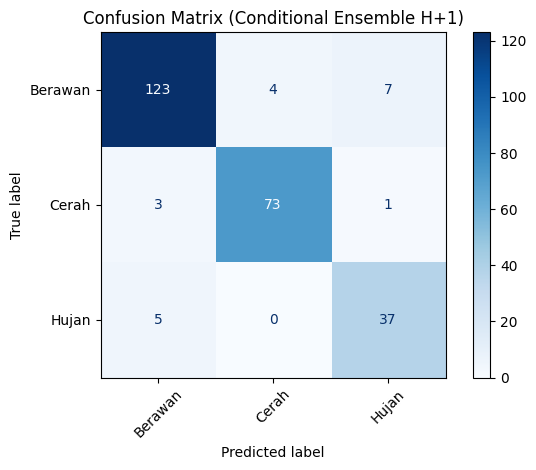

In [24]:
print("\n=== Evaluasi Conditional Ensemble (H+1) ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='macro')
print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred),
                              display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (Conditional Ensemble H+1)")
plt.tight_layout()
plt.show()

### Conditional Ensemble Model (Integrasi CNN + BiLSTM + TCN)

Bagian ini membangun **model ensemble adaptif** yang menggabungkan CNN (gambar awan) dengan BiLSTM dan TCN (time series cuaca), menggunakan bobot berbeda untuk siang/malam.

#### 1. Input Layer
- **`img_input`** → input gambar awan sesuai dimensi CNN.  
- **`ts_input`** → input time series dengan panjang sequence `SEQ_LEN` dan jumlah fitur `required_dim`.  
- **`mask_day`** → input indikator siang/malam (1 = siang, 0 = malam).

#### 2. Output Model Individu
- **`out_cnn = cnn_model(img_input)`** → prediksi CNN dari gambar awan.  
- **`out_bilstm = bilstm_model(ts_input)`** → prediksi BiLSTM dari data time series.  
- **`out_tcn = tcn_model(ts_input)`** → prediksi TCN dari data time series.

#### 3. Forecasting Rata-rata
- **`out_fc = (out_bilstm + out_tcn) / 2.0`**  
  - Menggabungkan BiLSTM dan TCN dengan **soft voting rata-rata**.  
  - Memberikan prediksi forecasting yang lebih stabil.

#### 4. Normalisasi Probabilitas
- Fungsi **`norm`** memastikan output tiap model adalah distribusi probabilitas valid (jumlah = 1).  
- **`cnn_norm`** → normalisasi output CNN.  
- **`fc_norm`** → normalisasi output forecasting (BiLSTM + TCN).

#### 5. Conditional Blending
- **`alpha_day_const = ALPHA_DAY`** → bobot CNN saat siang.  
- **`alpha_vec_t = alpha_day_const * mask_day`** → bobot CNN aktif hanya saat siang.  
- **`beta_vec_t = 1.0 - alpha_day_const * mask_day`** → bobot forecasting (BiLSTM + TCN).  
- **`blend`** → menggabungkan CNN dan forecasting sesuai bobot adaptif.  
- **`ens_norm`** → normalisasi hasil ensemble agar tetap valid.

#### 6. Model Ensemble
- **`ensemble_model = Model(inputs=[img_input, ts_input, mask_day], outputs=probs_ens_out)`**  
  - Membuat model Keras dengan tiga input (gambar, time series, mask siang/malam).  
  - Output: probabilitas prediksi cuaca H+1 hasil conditional ensemble.

#### 7. Penyimpanan Model
- **`os.makedirs("../Result Model", exist_ok=True)`** → membuat folder hasil jika belum ada.  
- **`ensemble_model.save(save_path)`** → menyimpan model ke file `model_conditional_ensemble_h1.h5`.  
- **`print(...)`** → menampilkan informasi lokasi penyimpanan.

#### 8. Catatan
- Model ini siap dipakai untuk inference langsung dengan input gabungan (gambar awan + data cuaca + indikator siang/malam).  
- Pendekatan ini meningkatkan akurasi dengan memanfaatkan kekuatan CNN di siang hari dan forecasting time series di malam hari.

In [25]:
img_input = Input(shape=cnn_model.input_shape[1:], name="img_input")
ts_input  = Input(shape=(SEQ_LEN, required_dim), name="ts_input")
mask_day  = Input(shape=(1,), name="mask_day")

out_cnn    = cnn_model(img_input)
out_bilstm = bilstm_model(ts_input)
out_tcn    = tcn_model(ts_input)

# Forecasting rata-rata BiLSTM + TCN
out_fc = Lambda(lambda x: (x[0] + x[1]) / 2.0, name="fc_avg")([out_bilstm, out_tcn])

# Normalisasi
norm = lambda x: x / tf.clip_by_value(tf.reduce_sum(x, axis=-1, keepdims=True), 1e-9, np.inf)
out_cnn = Lambda(norm, name="cnn_norm")(out_cnn)
out_fc  = Lambda(norm, name="fc_norm")(out_fc)

# Conditional blend: siang pakai ALPHA_DAY, malam 0
alpha_day_const = tf.constant(ALPHA_DAY, dtype=tf.float32)
alpha_vec_t = Lambda(lambda m: alpha_day_const * m, name="alpha_vec")(mask_day)
beta_vec_t  = Lambda(lambda m: 1.0 - alpha_day_const * m, name="beta_vec")(mask_day)

probs_ens_out = Lambda(lambda x: x[0]*x[2] + x[1]*x[3], name="blend")([out_cnn, out_fc, alpha_vec_t, beta_vec_t])
probs_ens_out = Lambda(norm, name="ens_norm")(probs_ens_out)

ensemble_model = Model(inputs=[img_input, ts_input, mask_day], outputs=probs_ens_out, name="conditional_ensemble_h1")

os.makedirs("../Result Model", exist_ok=True)
save_path = "../Result Model/model_conditional_ensemble_h1.h5"
ensemble_model.save(save_path)
print(f"[INFO] Conditional ensemble model saved to: {save_path}")

[INFO] Conditional ensemble model saved to: ../Result Model/model_conditional_ensemble_h1.h5


In [26]:
# Simpan ke format SavedModel (folder)
save_path = "../Result Model/conditional_ensemble_h1_savedmodel"
ensemble_model.save(save_path, save_format="tf")

print(f"[INFO] Conditional ensemble model saved to: {save_path}")

INFO:tensorflow:Assets written to: ../Result Model/conditional_ensemble_h1_savedmodel\assets


INFO:tensorflow:Assets written to: ../Result Model/conditional_ensemble_h1_savedmodel\assets


[INFO] Conditional ensemble model saved to: ../Result Model/conditional_ensemble_h1_savedmodel


In [27]:
import shutil

# Path folder SavedModel
save_path = "../Result Model/conditional_ensemble_h1_savedmodel"

# Buat file zip dari folder SavedModel
zip_path = "../Result Model/conditional_ensemble_h1_savedmodel_zip"
shutil.make_archive(zip_path, 'zip', save_path)

print(f"[INFO] SavedModel folder zipped to: {zip_path}.zip")


[INFO] SavedModel folder zipped to: ../Result Model/conditional_ensemble_h1_savedmodel_zip.zip


# Uji dan Evaluasi Tambahan

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from scipy.stats import ttest_rel

# 1. Confusion matrix & classification report untuk semua model
def evaluate_model(y_true, y_pred, class_names, title="Model"):
    print(f"\n=== {title} Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    print(f"\n=== {title} Confusion Matrix (angka) ===")
    print(df_cm)
    return df_cm

# Prediksi masing-masing model
preds_cnn = np.argmax(probs_cnn_trim, axis=1)
preds_bilstm = np.argmax(probs_bilstm[:N], axis=1)
preds_tcn = np.argmax(probs_tcn[:N], axis=1)
preds_ens = np.argmax(probs_ens, axis=1)

evaluate_model(y_true, preds_cnn, class_names, "CNN")
evaluate_model(y_true, preds_bilstm, class_names, "BiLSTM")
evaluate_model(y_true, preds_tcn, class_names, "TCN")
evaluate_model(y_true, preds_ens, class_names, "Conditional Ensemble")

# 2. Uji signifikansi antar model (paired t-test)
def paired_ttest(y_true, preds_a, preds_b, name_a, name_b):
    correct_a = (y_true == preds_a).astype(int)
    correct_b = (y_true == preds_b).astype(int)
    t_stat, p_val = ttest_rel(correct_a, correct_b)
    print(f"Paired t-test {name_a} vs {name_b}: t={t_stat:.4f}, p={p_val:.4f}")

paired_ttest(y_true, preds_bilstm, preds_tcn, "BiLSTM", "TCN")
paired_ttest(y_true, preds_bilstm, preds_ens, "BiLSTM", "Ensemble")
paired_ttest(y_true, preds_tcn, preds_ens, "TCN", "Ensemble")
paired_ttest(y_true, preds_cnn, preds_ens, "CNN", "Ensemble")

# 3. Tabel komparasi fitur training vs deployment
training_features = [
    "Temperature", "Humidity", "Pressure", "Solar Radiation",
    "Wind Speed", "Wind Direction",
    "Hour_sin", "Hour_cos", "Day_sin", "Day_cos", "Month_sin", "Month_cos",
    "Lag features (temp_diff3, temp_diff6, rh_diff3, rh_diff6, press_diff3, press_diff6)",
    "Rolling stats (rad_std3, rad_std6)"
]
deployment_features = ["Temperature", "Humidity", "Rainfall", "Wind Speed", "Cloud Cover"]

df_feat = pd.DataFrame({
    "Training Features (BMKG + engineered)": training_features,
    "Deployment Features (OWM API)": deployment_features + ["-"]*(len(training_features)-len(deployment_features))
})
print("\n=== Komparasi Fitur Training vs Deployment ===")
print(df_feat)



=== CNN Classification Report ===
              precision    recall  f1-score   support

     Berawan      0.548     0.172     0.261       134
       Cerah      0.301     0.688     0.419        77
       Hujan      0.229     0.190     0.208        42

    accuracy                          0.332       253
   macro avg      0.359     0.350     0.296       253
weighted avg      0.420     0.332     0.300       253


=== CNN Confusion Matrix (angka) ===
         Berawan  Cerah  Hujan
Berawan       23     94     17
Cerah         14     53     10
Hujan          5     29      8

=== BiLSTM Classification Report ===
              precision    recall  f1-score   support

     Berawan      0.936     0.873     0.903       134
       Cerah      0.937     0.961     0.949        77
       Hujan      0.755     0.881     0.813        42

    accuracy                          0.901       253
   macro avg      0.876     0.905     0.888       253
weighted avg      0.906     0.901     0.902       253


==

In [53]:
# Siang = 1 → CNN + Forecasting
# Malam = 0 → Forecasting saja

alpha_vec = day_mask * ALPHA_DAY      # siang = ALPHA_DAY, malam = 0
beta_vec  = 1.0 - alpha_vec           # siang = 1-ALPHA_DAY, malam = 1

probs_ens = alpha_vec * probs_cnn_trim + beta_vec * probs_fc_trim
probs_ens = probs_ens / np.clip(probs_ens.sum(axis=1, keepdims=True), 1e-9, None)

y_pred = np.argmax(probs_ens, axis=1)


In [54]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

mask_day = (is_day == 1)
mask_night = (is_day == 0)

y_true_day = y_true[mask_day]
y_pred_day = y_pred[mask_day]

y_true_night = y_true[mask_night]
y_pred_night = y_pred[mask_night]

print("\n=== PERFORMANCE BY TIME CONDITION ===\n")

# ===================== SIANG =====================
print(">>> DAYTIME (06–18)")
print("Samples:", len(y_true_day))
print("Accuracy:", accuracy_score(y_true_day, y_pred_day))
print("Macro F1:", f1_score(y_true_day, y_pred_day, average='macro'))
print(classification_report(y_true_day, y_pred_day, target_names=class_names))

# ===================== MALAM =====================
print("\n>>> NIGHTTIME (18–06)")
print("Samples:", len(y_true_night))
print("Accuracy:", accuracy_score(y_true_night, y_pred_night))
print("Macro F1:", f1_score(y_true_night, y_pred_night, average='macro'))
print(classification_report(y_true_night, y_pred_night, target_names=class_names))



=== PERFORMANCE BY TIME CONDITION ===

>>> DAYTIME (06–18)
Samples: 142
Accuracy: 0.9084507042253521
Macro F1: 0.8879268879268879
              precision    recall  f1-score   support

     Berawan       0.94      0.89      0.91        72
       Cerah       0.94      0.96      0.95        49
       Hujan       0.75      0.86      0.80        21

    accuracy                           0.91       142
   macro avg       0.88      0.90      0.89       142
weighted avg       0.91      0.91      0.91       142


>>> NIGHTTIME (18–06)
Samples: 111
Accuracy: 0.9369369369369369
Macro F1: 0.9314054834054833
              precision    recall  f1-score   support

     Berawan       0.94      0.95      0.94        62
       Cerah       0.96      0.93      0.95        28
       Hujan       0.90      0.90      0.90        21

    accuracy                           0.94       111
   macro avg       0.93      0.93      0.93       111
weighted avg       0.94      0.94      0.94       111



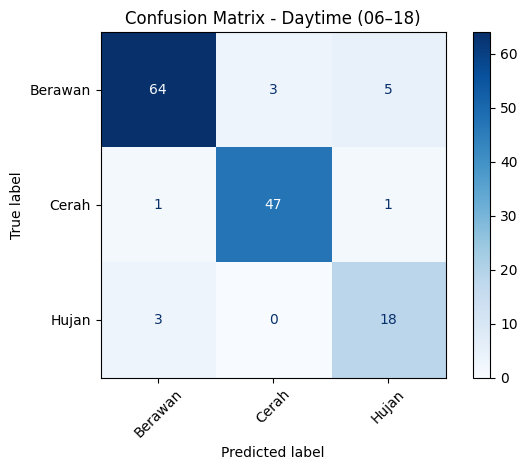

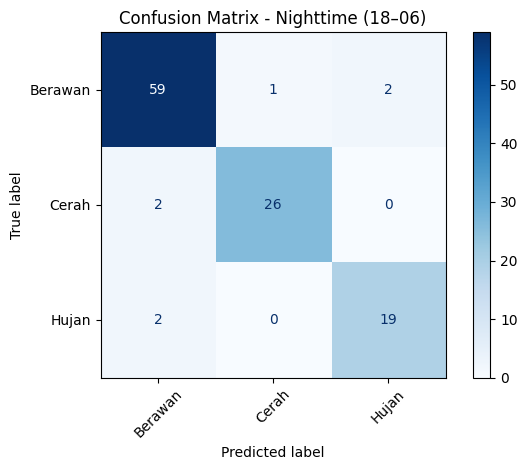

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# === CONFUSION MATRIX SIANG ===
cm_day = confusion_matrix(y_true_day, y_pred_day)
disp_day = ConfusionMatrixDisplay(confusion_matrix=cm_day, display_labels=class_names)
disp_day.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Daytime (06–18)")
plt.tight_layout()
plt.show()

# === CONFUSION MATRIX MALAM ===
cm_night = confusion_matrix(y_true_night, y_pred_night)
disp_night = ConfusionMatrixDisplay(confusion_matrix=cm_night, display_labels=class_names)
disp_night.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Nighttime (18–06)")
plt.tight_layout()
plt.show()


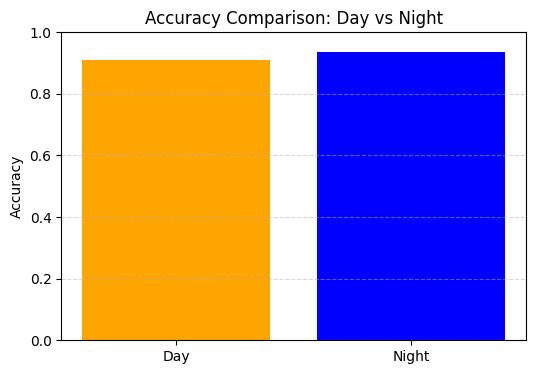

In [56]:
acc_day = accuracy_score(y_true_day, y_pred_day)
acc_night = accuracy_score(y_true_night, y_pred_night)

plt.figure(figsize=(6,4))
plt.bar(["Day", "Night"], [acc_day, acc_night], color=["orange","blue"])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Day vs Night")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


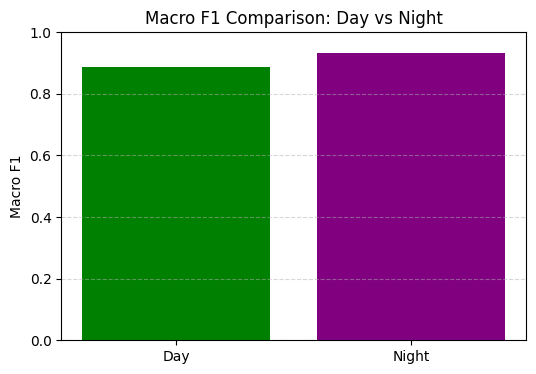

In [57]:
f1_day = f1_score(y_true_day, y_pred_day, average='macro')
f1_night = f1_score(y_true_night, y_pred_night, average='macro')

plt.figure(figsize=(6,4))
plt.bar(["Day", "Night"], [f1_day, f1_night], color=["green","purple"])
plt.ylim(0,1)
plt.ylabel("Macro F1")
plt.title("Macro F1 Comparison: Day vs Night")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()
